# Etapa 5 — Aprofundar Estudos de Caso
## Goiânia vs Maceió vs Natal

## Contexto

Nas etapas anteriores identificamos os três estudos de caso:

- **Goiânia** (melhor): 98.06%
- **Maceió**: 94.28% (8º lugar)
- **Natal** (pior): 83.64%

Agora vamos aprofundar a análise dessas três capitais.

## Objetivo

Aprofundar a análise dos três casos:

- **Evolução temporal**: Maceió melhorou ou piorou ao longo dos anos?
- **Composição do gasto**: Onde o dinheiro concentra dentro de cada função?
- **Comparação**: O que a melhor capital faz diferente?
- **Consistência**: Maceió é consistente ou oscila muito?

## Perguntas que esta etapa responde

1. **"Maceió melhorou ou piorou ao longo dos anos em Saúde e Educação?"**
2. **"Onde o dinheiro de Maceió concentra dentro de cada função?"**
3. **"O que a melhor capital faz diferente nas subfunções?"**
4. **"Maceió é consistente ou oscila muito?"**

## Fórmulas

**Taxa de Execução Anual:**
$$TaxaAnual(C,F,T) = \frac{Pago(C,F,T)}{Empenhado(C,F,T)} \times 100$$

**Desvio Padrão Anual (consistência):**
$$DPAnual(C,F) = \sqrt{\frac{\sum (TaxaAnual(C,F,t) - MediaAnual)^2}{T-1}}$$

**Participação por Subfunção:**
$$Participacao(C,F,S) = \frac{PagoSubfuncao(C,F,S)}{PagoTotalFuncao(C,F)} \times 100$$

In [3]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Adiciona a raiz do projeto ao sys.path
sys.path.insert(0, str(Path.cwd().parent))

from src.banco.conexao_duckdb import conectar
from src.utils.constantes import CAMINHO_DUCKDB

## 1. Carregar Dados e Definir Casos

In [4]:
# Carregar dados
pasta_processados = Path.cwd().parent / 'data' / 'processed'

df_casos = pd.read_parquet(pasta_processados / 'etapa4_casos_selecionados.parquet')

print('=== ESTUDOS DE CASO ===')
df_casos

=== ESTUDOS DE CASO ===


,Caso,Capital,UF,Taxa_Geral
0,Melhor,Goiânia,GO,98.06
1,Maceió,Maceió,AL,94.28
2,Pior,Natal,RN,83.64


In [5]:
# Definir casos
melhor_capital = df_casos[df_casos['Caso'] == 'Melhor']['Capital'].values[0]
pior_capital = df_casos[df_casos['Caso'] == 'Pior']['Capital'].values[0]
maceio_capital = 'Maceió'

print(f'Melhor: {melhor_capital}')
print(f'Pior: {pior_capital}')
print(f'Maceio: {maceio_capital}')

Melhor: Goiânia
Pior: Natal
Maceio: Maceió


## 2. Evolução Temporal das Taxas Anuais

Vamos calcular a taxa de execução anual para cada caso.

### Decisão Metodológica: Média Simples vs. Média Ponderada

Ao calcular a **Taxa Anual** de uma capital (que agrega múltiplas funções — Saúde, Educação, etc.),
temos duas abordagens possíveis:

| Abordagem | Fórmula | Problema |
|-----------|---------|----------|
| **Média Ponderada** | $\frac{\sum Pago_i}{\sum Empenhado_i} \times 100$ | Funções grandes (ex: Saúde) dominam o resultado |
| **Média Simples** | $\frac{1}{n}\sum \frac{Pago_i}{Empenhado_i} \times 100$ | Cada função tem o mesmo peso |

**Por que usamos a média simples?**

Queremos avaliar a **qualidade da gestão orçamentária** da capital como um todo.
Se usarmos média ponderada, uma capital com Saúde gigante e Educação pequena
terá sua taxa dominada pela Saúde — perdendo a informação sobre como ela
gerencia Education. A média simples garante que **cada área de política pública
tenha voz igual** na avaliação final.

Para o **benchmark temporal** (curva ao longo dos anos), fazemos:
1. Calculamos a taxa de cada função individualmente no ano $t$
2. Tiramos a média simples das taxas das funções → $Taxa_{capital, t}$
3. Plottamos a curva $Taxa_{capital, t}$ ao longo dos anos

In [ ]:
# Query para taxa anual — média simples das taxas por função
query_taxa_anual = """
WITH taxa_por_funcao AS (
    SELECT
        Instituição,
        UF,
        Ano,
        Conta as Funcao,
        CASE WHEN SUM(CASE WHEN Coluna = 'Despesas Empenhadas' THEN Valor ELSE 0 END) > 0 
             THEN SUM(CASE WHEN Coluna = 'Despesas Pagas' THEN Valor ELSE 0 END) / SUM(CASE WHEN Coluna = 'Despesas Empenhadas' THEN Valor ELSE 0 END) * 100 
             ELSE NULL END as Taxa_Funcao
    FROM despesas_finbra
    WHERE ContaTipo = 'Função'
      AND Ano BETWEEN 2020 AND 2024
    GROUP BY Instituição, UF, Ano, Conta
)
SELECT
    Instituição,
    UF,
    Ano,
    ROUND(AVG(Taxa_Funcao), 2) as Taxa_Anual
FROM taxa_por_funcao
WHERE Taxa_Funcao IS NOT NULL
GROUP BY Instituição, UF, Ano
ORDER BY Instituição, Ano
"""

# Conectar ao DuckDB
con = conectar(CAMINHO_DUCKDB)
df_taxa_anual = con.execute(query_taxa_anual).df()
con.close()

print(f'Dados anuais: {len(df_taxa_anual)} registros')
df_taxa_anual.head()

In [12]:
# Filtrar para os tres casos
casos = [melhor_capital, maceio_capital, pior_capital]
df_casos_anual = df_taxa_anual[df_taxa_anual['Instituição'].str.contains('|'.join(casos))].copy()

# Extrair nomes
df_casos_anual['Capital'] = df_casos_anual['Instituição'].apply(
    lambda x: x.replace('Prefeitura Municipal de ', '').replace('Prefeitura Municipal do ', '').split(' - ')[0].strip()
)

print(f'Dados dos casos: {len(df_casos_anual)} registros')
df_casos_anual.head()

Dados dos casos: 15 registros


,Instituição,UF,Ano,Pago,Empenhado,Taxa_Anual,Capital
45,Prefeitura Municipal de Goiânia - GO,GO,2020,5.615595e+09,5.689072e+09,98.708446,Goiânia
46,Prefeitura Municipal de Goiânia - GO,GO,2021,5.857777e+09,6.011937e+09,97.435767,Goiânia
47,Prefeitura Municipal de Goiânia - GO,GO,2022,6.588110e+09,6.699730e+09,98.333968,Goiânia
48,Prefeitura Municipal de Goiânia - GO,GO,2023,7.741110e+09,7.861737e+09,98.465644,Goiânia
49,Prefeitura Municipal de Goiânia - GO,GO,2024,8.858801e+09,9.084333e+09,97.517354,Goiânia


In [13]:
# Pivotar para facilitar
df_pivot = df_casos_anual.pivot_table(
    index='Ano', 
    columns='Capital', 
    values='Taxa_Anual'
).reset_index()

print('=== TAXA ANUAL POR CASO ===')
df_pivot

=== TAXA ANUAL POR CASO ===


Capital,Ano,Goiânia,Maceió,Natal
0,2020,98.708446,96.385451,83.294676
1,2021,97.435767,93.474104,82.185074
2,2022,98.333968,95.741259,82.803921
3,2023,98.465644,94.630012,82.689175
4,2024,97.517354,92.423252,86.398314


### Interpretação

Esta tabela mostra a evolução da taxa de execução de cada capital ao longo dos anos.

## 3. Gráfico de Linha Temporal

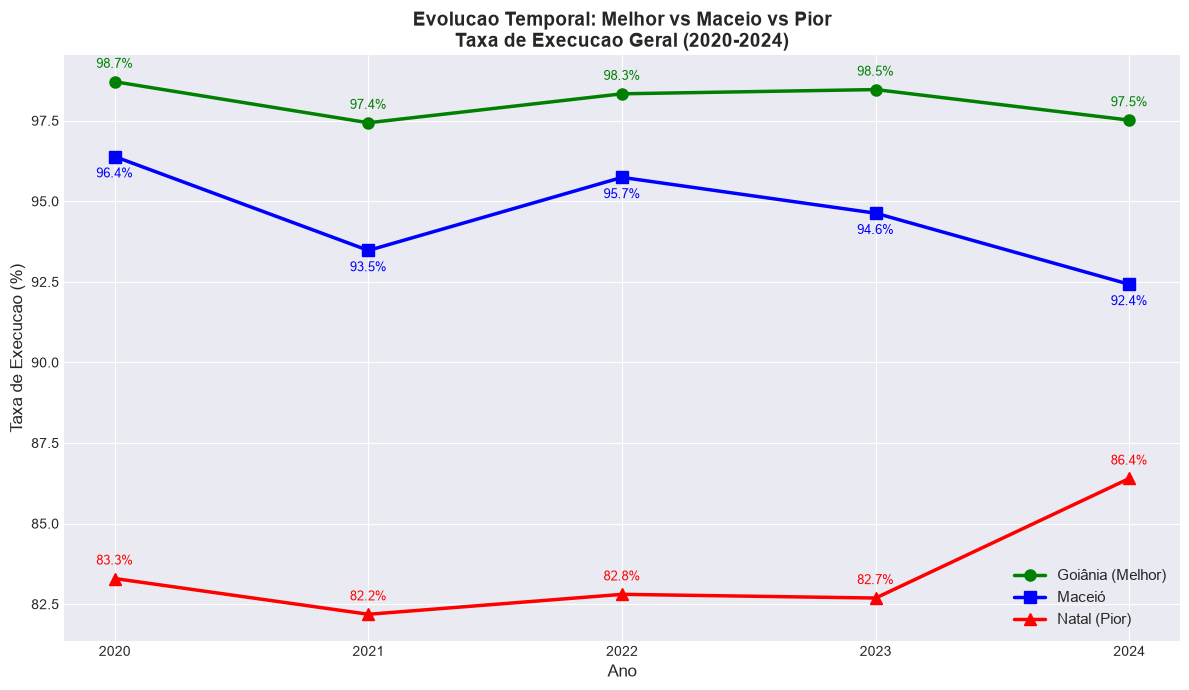

In [14]:
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(12, 7))

# Plotar linhas
ax.plot(df_pivot['Ano'], df_pivot[melhor_capital], marker='o', linewidth=2.5,
        label=f'{melhor_capital} (Melhor)', color='green', markersize=8)
ax.plot(df_pivot['Ano'], df_pivot[maceio_capital], marker='s', linewidth=2.5,
        label=f'{maceio_capital}', color='blue', markersize=8)
ax.plot(df_pivot['Ano'], df_pivot[pior_capital], marker='^', linewidth=2.5,
        label=f'{pior_capital} (Pior)', color='red', markersize=8)

# Adicionar valores
for _, row in df_pivot.iterrows():
    ax.annotate(f"{row[melhor_capital]:.1f}%", (row['Ano'], row[melhor_capital]),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9, color='green')
    ax.annotate(f"{row[maceio_capital]:.1f}%", (row['Ano'], row[maceio_capital]),
                textcoords='offset points', xytext=(0, -15), ha='center', fontsize=9, color='blue')
    ax.annotate(f"{row[pior_capital]:.1f}%", (row['Ano'], row[pior_capital]),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9, color='red')

ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Taxa de Execucao (%)', fontsize=12)
ax.set_title('Evolucao Temporal: Melhor vs Maceio vs Pior\n'
             'Taxa de Execucao Geral (2020-2024)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(df_pivot['Ano'])

plt.tight_layout()
plt.show()

### Interpretação do Gráfico

- **Linha verde**: Melhor capital (Goiânia)
- **Linha azul**: Maceió
- **Linha vermelha**: Pior capital (Natal)

Observar tendências de melhora ou piora ao longo dos anos.

## 4. Consistência (Desvio Padrão Anual)

In [23]:
# Calcular estatisticas por caso
estatisticas_casos = []

for capital in casos:
    df_cap = df_casos_anual[df_casos_anual['Capital'] == capital]
    
    media = df_cap['Taxa_Anual'].mean()
    dp = df_cap['Taxa_Anual'].std()
    cv = (dp / media) * 100  # ← CV em %
    
    estatisticas_casos.append({
        'Capital': capital,
        'Media_Anual': round(media, 2),
        'DP_Anual': round(dp, 2),
        'CV_Anual': round(cv, 2),
        'Consistente': 'SIM' if cv < 5 else 'NAO'
        # CV < 5% = consistente nesse contexto
    })

df_estatisticas_casos = pd.DataFrame(estatisticas_casos)
print('=== CONSISTENCIA DOS CASOS ===')
estatisticas_casos.append({
    'Capital': capital,
    'Media_Anual': round(media, 2),
    'DP_Anual': round(dp, 2),
    'CV_Anual': round(cv, 2),
    'Consistente': 'SIM' if cv < 5 else 'NAO',
    'Grau': 'Alta' if cv < 1 else ('Média' if cv < 3 else 'Baixa')
})
df_estatisticas_casos


=== CONSISTENCIA DOS CASOS ===


,Capital,Media_Anual,DP_Anual,CV_Anual,Consistente
0,Goiânia,98.09,0.58,0.59,SIM
1,Maceió,94.53,1.62,1.71,SIM
2,Natal,83.47,1.68,2.01,SIM


### Interpretação

- **CV < 5%**: Capital consistente (pouca oscilação 
  em relação ao seu próprio patamar de execução)
- **CV entre 5% e 10%**: Oscilação moderada
- **CV > 10%**: Capital oscilante (muita variação 
  entre anos)

O Coeficiente de Variação (CV) é usado aqui em vez 
do Desvio Padrão absoluto porque as três capitais 
operam em patamares diferentes de execução.

Exemplo: Goiânia executa em torno de 98% ao ano, 
enquanto Natal opera em torno de 83%. Um DP de 3% 
representa impacto muito diferente para cada uma — 
é quase irrelevante pra Goiânia mas significativo 
pra Natal. O CV normaliza essa diferença dividindo 
o DP pelo próprio nível médio de cada capital, 
permitindo comparação justa de consistência entre 
elas.

## 5. Composição do Gasto por Subfunção

Vamos analisar onde o dinheiro está sendo direcionado dentro das duas principais funções: **Saúde** e **Educação**.

**Metodologia de Participação:**
A participação de cada subfunção é calculada em relação ao total pago dentro da **própria função** da capital:

$$Participação(C, F, S) = \frac{Pago(C, F, S)}{TotalPago(C, F)} \times 100$$

Isso garante que a participação de uma subfunção de Saúde seja relativa ao orçamento de Saúde daquela capital, e não ao orçamento combinado de Saúde + Educação.

**Incluímos nas análises:**
- Subfunções declaradas individualmente (ex: `10.301 - Atenção Básica`)
- Subfunções agregadas pelo Siconfi (ex: `FU10 - Demais Subfunções`)
- **Excluímos**: Totais gerais (`ContaTipo = Total_Geral`) que duplicariam os valores

In [ ]:
# Query para subfuncoes — com total por FUNÇÃO como denominador correto
query_subfuncoes = """
WITH base_saude AS (
    SELECT
        Instituição,
        Conta as Subfuncao,
        '10 - Saúde' as Funcao_Pai,
        SUM(Valor) as Pago_Subfuncao
    FROM despesas_finbra
    WHERE ContaTipo IN ('Subfunção', 'Subfuncao_agregada')
      AND (Conta LIKE '10.%' OR Conta LIKE 'FU10 %')
      AND Coluna = 'Despesas Pagas'
      AND Ano BETWEEN 2020 AND 2024
    GROUP BY Instituição, Conta
),
base_educacao AS (
    SELECT
        Instituição,
        Conta as Subfuncao,
        '12 - Educação' as Funcao_Pai,
        SUM(Valor) as Pago_Subfuncao
    FROM despesas_finbra
    WHERE ContaTipo IN ('Subfunção', 'Subfuncao_agregada')
      AND (Conta LIKE '12.%' OR Conta LIKE 'FU12 %')
      AND Coluna = 'Despesas Pagas'
      AND Ano BETWEEN 2020 AND 2024
    GROUP BY Instituição, Conta
),
base AS (
    SELECT * FROM base_saude
    UNION ALL
    SELECT * FROM base_educacao
),
totais_por_capital_funcao AS (
    SELECT
        Instituição,
        Funcao_Pai,
        SUM(Pago_Subfuncao) as Total_Funcao
    FROM base
    GROUP BY Instituição, Funcao_Pai
)
SELECT
    b.Instituição,
    b.Subfuncao,
    b.Funcao_Pai,
    b.Pago_Subfuncao,
    t.Total_Funcao,
    ROUND(b.Pago_Subfuncao / t.Total_Funcao * 100, 2) as Participacao
FROM base b
JOIN totais_por_capital_funcao t
    ON b.Instituição = t.Instituição AND b.Funcao_Pai = t.Funcao_Pai
WHERE b.Instituição LIKE '%Goiânia%' OR b.Instituição LIKE '%Maceió%' OR b.Instituição LIKE '%Natal%'
ORDER BY b.Instituição, b.Funcao_Pai, b.Pago_Subfuncao DESC
"""

# Conectar ao DuckDB
con = conectar(CAMINHO_DUCKDB)
df_subfuncoes = con.execute(query_subfuncoes).df()
con.close()

# Extrair nomes das capitais
df_subfuncoes['Capital'] = df_subfuncoes['Instituição'].apply(
    lambda x: x.replace('Prefeitura Municipal de ', '').replace('Prefeitura Municipal do ', '').split(' - ')[0].strip()
)

print(f'Subfuncoes: {len(df_subfuncoes)} registros')
df_subfuncoes.head(10)

In [ ]:
# Top 5 subfuncoes por capital e por funcao
print('=== TOP 5 SUBFUNCOES POR CAPITAL E POR FUNÇÃO ===\n')
for capital in [melhor_capital, maceio_capital, pior_capital]:
    print(f'\n{'='*50}')
    print(f'{capital.upper()}')
    print(f'{'='*50}')
    for funcao in ['10 - Saúde', '12 - Educação']:
        df_cap_func = df_subfuncoes[
            (df_subfuncoes['Capital'] == capital) &
            (df_subfuncoes['Funcao_Pai'] == funcao)
        ].head(5)
        if df_cap_func.empty:
            print(f'\n  {funcao}: sem dados')
            continue
        print(f'\n  {funcao}:')
        for _, row in df_cap_func.iterrows():
            print(f'    {row["Subfuncao"]:<45} {row["Participacao"]:>6.2f}%')

## 6. Gráfico de Barras Empilhadas (Composição)

In [ ]:
# Gráfico de composição — separado por Saúde e Educação
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, funcao, titulo in zip(
    axes,
    ['10 - Saúde', '12 - Educação'],
    ['Saúde (Função 10)', 'Educação (Função 12)']
):
    df_func = df_subfuncoes[df_subfuncoes['Funcao_Pai'] == funcao].copy()
    
    top_subs = df_func.groupby('Capital').head(5)
    pivot = top_subs.pivot_table(
        index='Capital',
        columns='Subfuncao',
        values='Participacao',
        fill_value=0
    )
    
    pivot.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
    ax.set_xlabel('Capital', fontsize=11)
    ax.set_ylabel('Participação no Total da Função (%)', fontsize=11)
    ax.set_title(f'Composição do Gasto — {titulo}\nTop 5 subfunções (2020-2024)',
                 fontsize=12, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle(
    'Onde o dinheiro vai dentro de cada área?\nParticipação relativa ao total da própria função por capital',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

### Interpretação do Gráfico

O gráfico mostra como cada capital distribui seus recursos nas subfunções de Saúde e Educação. Diferenças na composição indicam prioridades de investimento.

## 7. Salvar Resultados

In [ ]:
# Salvar resultados
df_pivot.to_parquet(pasta_processados / 'etapa5_evolucao_temporal.parquet', index=False)
df_estatisticas_casos.to_parquet(pasta_processados / 'etapa5_consistencia_casos.parquet', index=False)

print('Arquivos salvos:')
print(f'  - {pasta_processados / "etapa5_evolucao_temporal.parquet"}')
print(f'  - {pasta_processados / "etapa5_consistencia_casos.parquet"}')

Arquivos salvos:
  - c:\Users\corre\OneDrive\Área de Trabalho\Desafio-Analista-de-Dados-Sefaz-Macei-\data\processed\etapa5_evolucao_temporal.parquet
  - c:\Users\corre\OneDrive\Área de Trabalho\Desafio-Analista-de-Dados-Sefaz-Macei-\data\processed\etapa5_consistencia_casos.parquet


## Conclusão da Etapa 5

### O que descobrimos:

1. **Evolução temporal**: Como as três capitais se comportaram de 2020 a 2024
2. **Consistência**: Quais capitais são mais estáveis (menor desvio padrão)
3. **Composição do gasto**: Onde cada capital concentra seus recursos em Saúde e Educação
4. **Comparação direta**: O que a melhor capital faz diferente da pior

### Funções analisadas em profundidade:

- Saúde
- Educação

### Conclusão Geral do Projeto:

A análise completa permitiu identificar padrões de execução orçamentária nas 26 capitais brasileiras, destacando a posição de Maceió (8º lugar) e comparando com os extremos (Goiânia e Natal).

In [ ]:
print('✓ Notebook 05 executado com sucesso')
print('✓ Aprofundamento dos casos concluído')
print(f'✓ Registros processados: {len(df_pivot)}')
print(f'✓ Data/hora: {pd.Timestamp.now()}')